# Credit Risk Data Cleaning

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# we have two files 
# 1. internal dataset (bank)
# 2. external dataset (CIBIL)   -- purchase

# load both data set

In [3]:
df1 = pd.read_excel("case_study1.xlsx")
df2 = pd.read_excel("case_study2.xlsx")

In [4]:
print(df1.shape)
print(df1.columns)
print(df1.info())

(51336, 26)
Index(['PROSPECTID', 'Total_TL', 'Tot_Closed_TL', 'Tot_Active_TL',
       'Total_TL_opened_L6M', 'Tot_TL_closed_L6M', 'pct_tl_open_L6M',
       'pct_tl_closed_L6M', 'pct_active_tl', 'pct_closed_tl',
       'Total_TL_opened_L12M', 'Tot_TL_closed_L12M', 'pct_tl_open_L12M',
       'pct_tl_closed_L12M', 'Tot_Missed_Pmnt', 'Auto_TL', 'CC_TL',
       'Consumer_TL', 'Gold_TL', 'Home_TL', 'PL_TL', 'Secured_TL',
       'Unsecured_TL', 'Other_TL', 'Age_Oldest_TL', 'Age_Newest_TL'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51336 entries, 0 to 51335
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   PROSPECTID            51336 non-null  int64  
 1   Total_TL              51336 non-null  int64  
 2   Tot_Closed_TL         51336 non-null  int64  
 3   Tot_Active_TL         51336 non-null  int64  
 4   Total_TL_opened_L6M   51336 non-null  int64  
 5   Tot_TL_closed_L6M 

In [5]:
df1.describe()

,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,...,CC_TL,Consumer_TL,Gold_TL,Home_TL,PL_TL,Secured_TL,Unsecured_TL,Other_TL,Age_Oldest_TL,Age_Newest_TL
count,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,...,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000
mean,25668.500000,4.858598,2.770415,2.088184,0.736754,0.428919,0.184574,0.089095,0.577542,0.422458,...,0.124981,1.136084,1.561847,0.070146,0.282511,2.844904,2.013694,1.089762,-32.575639,-62.149525
std,14819.571046,7.177116,5.941680,2.290774,1.296717,0.989972,0.297414,0.205635,0.379867,0.379867,...,0.505201,2.227997,5.376434,0.340861,0.858168,6.187177,3.198322,2.417496,2791.869609,2790.818622
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-99999.000000,-99999.000000
25%,12834.750000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.250000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,4.000000
50%,25668.500000,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.556000,0.444000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,33.000000,8.000000
75%,38502.250000,5.000000,3.000000,3.000000,1.000000,1.000000,0.308000,0.053000,1.000000,0.750000,...,0.000000,1.000000,1.000000,0.000000,0.000000,3.000000,2.000000,1.000000,64.000000,17.000000
max,51336.000000,235.000000,216.000000,47.000000,27.000000,19.000000,1.000000,1.000000,1.000000,1.000000,...,27.000000,41.000000,235.000000,10.000000,29.000000,235.000000,55.000000,80.000000,392.000000,392.000000


In [6]:
print(df2.shape)
print(df2.columns)
print(df2.info())

(51336, 62)
Index(['PROSPECTID', 'time_since_recent_payment',
       'time_since_first_deliquency', 'time_since_recent_deliquency',
       'num_times_delinquent', 'max_delinquency_level',
       'max_recent_level_of_deliq', 'num_deliq_6mts', 'num_deliq_12mts',
       'num_deliq_6_12mts', 'max_deliq_6mts', 'max_deliq_12mts',
       'num_times_30p_dpd', 'num_times_60p_dpd', 'num_std', 'num_std_6mts',
       'num_std_12mts', 'num_sub', 'num_sub_6mts', 'num_sub_12mts', 'num_dbt',
       'num_dbt_6mts', 'num_dbt_12mts', 'num_lss', 'num_lss_6mts',
       'num_lss_12mts', 'recent_level_of_deliq', 'tot_enq', 'CC_enq',
       'CC_enq_L6m', 'CC_enq_L12m', 'PL_enq', 'PL_enq_L6m', 'PL_enq_L12m',
       'time_since_recent_enq', 'enq_L12m', 'enq_L6m', 'enq_L3m',
       'MARITALSTATUS', 'EDUCATION', 'AGE', 'GENDER', 'NETMONTHLYINCOME',
       'Time_With_Curr_Empr', 'pct_of_active_TLs_ever',
       'pct_opened_TLs_L6m_of_L12m', 'pct_currentBal_all_TL', 'CC_utilization',
       'CC_Flag', 'PL_utilizati

In [7]:
df2.describe()

,PROSPECTID,time_since_recent_payment,time_since_first_deliquency,time_since_recent_deliquency,num_times_delinquent,max_delinquency_level,max_recent_level_of_deliq,num_deliq_6mts,num_deliq_12mts,num_deliq_6_12mts,...,PL_utilization,PL_Flag,pct_PL_enq_L6m_of_L12m,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,max_unsec_exposure_inPct,HL_Flag,GL_Flag,Credit_Score
count,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,...,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000
mean,25668.500000,-8129.961314,-70020.091320,-70022.375838,1.573749,-70003.987085,13.521953,0.184977,0.480053,0.295076,...,-86556.225194,0.167874,0.190414,0.065182,0.170492,0.056302,-45127.943635,0.271116,0.052887,679.859222
std,14819.571046,27749.328514,45823.312757,45819.820741,4.165012,45847.976100,53.336976,0.710240,1.522210,1.027471,...,34111.414750,0.373758,0.376218,0.235706,0.350209,0.213506,49795.784556,0.444540,0.223810,20.502764
min,1.000000,-99999.000000,-99999.000000,-99999.000000,0.000000,-99999.000000,0.000000,0.000000,0.000000,0.000000,...,-99999.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-99999.000000,0.000000,0.000000,469.000000
25%,12834.750000,46.000000,-99999.000000,-99999.000000,0.000000,-99999.000000,0.000000,0.000000,0.000000,0.000000,...,-99999.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-99999.000000,0.000000,0.000000,669.000000
50%,25668.500000,70.000000,-99999.000000,-99999.000000,0.000000,-99999.000000,0.000000,0.000000,0.000000,0.000000,...,-99999.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.333000,0.000000,0.000000,680.000000
75%,38502.250000,161.000000,8.000000,3.000000,1.000000,15.000000,10.000000,0.000000,0.000000,0.000000,...,-99999.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.164250,1.000000,0.000000,691.000000
max,51336.000000,6065.000000,35.000000,35.000000,74.000000,900.000000,900.000000,12.000000,28.000000,20.000000,...,1.708000,1.000000,1.000000,1.000000,1.000000,1.000000,173800.000000,1.000000,1.000000,811.000000


In [8]:
df1.head(10)

,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,...,CC_TL,Consumer_TL,Gold_TL,Home_TL,PL_TL,Secured_TL,Unsecured_TL,Other_TL,Age_Oldest_TL,Age_Newest_TL
0,1,5,4,1,0,0,0.000,0.000,0.200,0.800,...,0,0,1,0,4,1,4,0,72,18
1,2,1,0,1,0,0,0.000,0.000,1.000,0.000,...,0,1,0,0,0,0,1,0,7,7
2,3,8,0,8,1,0,0.125,0.000,1.000,0.000,...,0,6,1,0,0,2,6,0,47,2
3,4,1,0,1,1,0,1.000,0.000,1.000,0.000,...,0,0,0,0,0,0,1,1,5,5
4,5,3,2,1,0,0,0.000,0.000,0.333,0.667,...,0,0,0,0,0,3,0,2,131,32
5,6,6,5,1,0,0,0.000,0.000,0.167,0.833,...,0,0,2,0,0,6,0,0,150,17
6,7,3,1,2,1,1,0.333,0.333,0.667,0.333,...,0,0,3,0,0,3,0,0,17,5
7,8,6,4,2,0,0,0.000,0.000,0.333,0.667,...,0,0,0,0,0,6,0,5,36,8
8,9,1,0,1,0,0,0.000,0.000,1.000,0.000,...,0,0,0,0,0,1,0,0,16,16
9,10,2,1,1,0,0,0.000,0.000,0.500,0.500,...,0,0,0,0,0,1,1,2,66,39


In [9]:
df2.head(10)

,PROSPECTID,time_since_recent_payment,time_since_first_deliquency,time_since_recent_deliquency,num_times_delinquent,max_delinquency_level,max_recent_level_of_deliq,num_deliq_6mts,num_deliq_12mts,num_deliq_6_12mts,...,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,max_unsec_exposure_inPct,HL_Flag,GL_Flag,last_prod_enq2,first_prod_enq2,Credit_Score,Approved_Flag
0,1,549,35,15,11,29,29,0,0,0,...,0.0,0.000,0.0,13.333,1,0,PL,PL,696,P2
1,2,47,-99999,-99999,0,-99999,0,0,0,0,...,0.0,0.000,0.0,0.860,0,0,ConsumerLoan,ConsumerLoan,685,P2
2,3,302,11,3,9,25,25,1,9,8,...,0.0,0.000,0.0,5741.667,1,0,ConsumerLoan,others,693,P2
3,4,-99999,-99999,-99999,0,-99999,0,0,0,0,...,0.0,0.000,0.0,9.900,0,0,others,others,673,P2
4,5,583,-99999,-99999,0,-99999,0,0,0,0,...,0.0,0.000,0.0,-99999.000,0,0,AL,AL,753,P1
5,6,245,27,18,14,300,270,0,0,0,...,0.0,0.429,0.0,-99999.000,1,0,ConsumerLoan,PL,668,P3
6,7,49,-99999,-99999,0,-99999,0,0,0,0,...,0.0,0.000,0.0,-99999.000,1,0,others,others,703,P1
7,8,74,23,12,3,164,133,0,0,0,...,0.0,0.000,0.0,-99999.000,0,0,ConsumerLoan,others,676,P2
8,9,424,7,4,3,99,38,2,3,1,...,0.0,0.000,0.0,-99999.000,0,0,ConsumerLoan,others,658,P4
9,10,39,-99999,-99999,0,-99999,0,0,0,0,...,0.0,0.000,0.0,3.333,0,0,others,others,705,P1


In [10]:
print("df1 duplicate IDs:", df1["PROSPECTID"].duplicated().sum())
print("df2 duplicate IDs:", df2["PROSPECTID"].duplicated().sum())

print("df1 unique IDs:", df1["PROSPECTID"].nunique())
print("df2 unique IDs:", df2["PROSPECTID"].nunique())

df1 duplicate IDs: 0
df2 duplicate IDs: 0
df1 unique IDs: 51336
df2 unique IDs: 51336


In [11]:
# Merge

In [16]:
df.dtypes

PROSPECTID              int64
Total_TL                int64
Tot_Closed_TL           int64
Tot_Active_TL           int64
Total_TL_opened_L6M     int64
                        ...  
GL_Flag                 int64
last_prod_enq2         object
first_prod_enq2        object
Credit_Score            int64
Approved_Flag          object
Length: 87, dtype: object

In [15]:
df = pd.merge(df1,df2,on="PROSPECTID" , how= "inner")

In [ ]:
df.shape

In [ ]:
# Data understanding

In [17]:
df["PROSPECTID"].duplicated().sum()

np.int64(0)

In [18]:
null_val = df.isnull().sum()

print(null_val[null_val > 0])

Series([], dtype: int64)


In [19]:
num_cols = df.select_dtypes(include="number").columns

df[num_cols] 

,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,...,PL_utilization,PL_Flag,pct_PL_enq_L6m_of_L12m,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,max_unsec_exposure_inPct,HL_Flag,GL_Flag,Credit_Score
0,1,5,4,1,0,0,0.000,0.00,0.200,0.800,...,0.798,1,0.0,0.0,0.0,0.0,13.333,1,0,696
1,2,1,0,1,0,0,0.000,0.00,1.000,0.000,...,-99999.000,0,0.0,0.0,0.0,0.0,0.860,0,0,685
2,3,8,0,8,1,0,0.125,0.00,1.000,0.000,...,-99999.000,0,0.0,0.0,0.0,0.0,5741.667,1,0,693
3,4,1,0,1,1,0,1.000,0.00,1.000,0.000,...,-99999.000,0,0.0,0.0,0.0,0.0,9.900,0,0,673
4,5,3,2,1,0,0,0.000,0.00,0.333,0.667,...,-99999.000,0,0.0,0.0,0.0,0.0,-99999.000,0,0,753
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51331,51332,3,0,3,1,0,0.333,0.00,1.000,0.000,...,-99999.000,0,0.0,0.0,0.0,0.0,1.661,0,0,650
51332,51333,4,2,2,0,1,0.000,0.25,0.500,0.500,...,-99999.000,0,0.0,0.0,0.0,0.0,0.520,0,0,702
51333,51334,2,1,1,1,1,0.500,0.50,0.500,0.500,...,-99999.000,0,1.0,0.0,1.0,0.0,0.567,0,0,661
51334,51335,2,1,1,0,0,0.000,0.00,0.500,0.500,...,-99999.000,0,0.0,0.0,0.0,0.0,1.202,0,0,686


In [20]:
df[num_cols] = df[num_cols].replace(-99999, np.nan)

print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 320792


In [21]:
missing = df.isnull().sum()
missing 

PROSPECTID             0
Total_TL               0
Tot_Closed_TL          0
Tot_Active_TL          0
Total_TL_opened_L6M    0
                      ..
GL_Flag                0
last_prod_enq2         0
first_prod_enq2        0
Credit_Score           0
Approved_Flag          0
Length: 87, dtype: int64

In [22]:
missing_data = pd.DataFrame({"Missing_Count": df.isnull().sum() ,
                 "missing_per" : (df.isnull().sum()/len(df))*100})

missing_data = (missing_data[missing_data["Missing_Count"] > 0]
    .sort_values("missing_per",ascending=False))


print(missing_data)

                              Missing_Count  missing_per
CC_utilization                        47636    92.792582
PL_utilization                        44435    86.557192
time_since_first_deliquency           35949    70.026882
time_since_recent_deliquency          35949    70.026882
max_delinquency_level                 35949    70.026882
max_unsec_exposure_inPct              23178    45.149603
max_deliq_6mts                        12890    25.109085
max_deliq_12mts                       10832    21.100203
PL_enq_L12m                            6321    12.312997
enq_L3m                                6321    12.312997
enq_L6m                                6321    12.312997
enq_L12m                               6321    12.312997
time_since_recent_enq                  6321    12.312997
CC_enq_L12m                            6321    12.312997
PL_enq_L6m                             6321    12.312997
PL_enq                                 6321    12.312997
CC_enq_L6m                     

In [23]:
high_missing = missing_data[missing_data["Missing_Count"] > 23000]

k=(high_missing.index)

In [24]:
df.drop(k,axis=1,inplace=True)

In [25]:
df

,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,...,pct_PL_enq_L6m_of_L12m,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,HL_Flag,GL_Flag,last_prod_enq2,first_prod_enq2,Credit_Score,Approved_Flag
0,1,5,4,1,0,0,0.000,0.00,0.200,0.800,...,0.0,0.0,0.0,0.0,1,0,PL,PL,696,P2
1,2,1,0,1,0,0,0.000,0.00,1.000,0.000,...,0.0,0.0,0.0,0.0,0,0,ConsumerLoan,ConsumerLoan,685,P2
2,3,8,0,8,1,0,0.125,0.00,1.000,0.000,...,0.0,0.0,0.0,0.0,1,0,ConsumerLoan,others,693,P2
3,4,1,0,1,1,0,1.000,0.00,1.000,0.000,...,0.0,0.0,0.0,0.0,0,0,others,others,673,P2
4,5,3,2,1,0,0,0.000,0.00,0.333,0.667,...,0.0,0.0,0.0,0.0,0,0,AL,AL,753,P1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51331,51332,3,0,3,1,0,0.333,0.00,1.000,0.000,...,0.0,0.0,0.0,0.0,0,0,ConsumerLoan,ConsumerLoan,650,P4
51332,51333,4,2,2,0,1,0.000,0.25,0.500,0.500,...,0.0,0.0,0.0,0.0,0,0,others,others,702,P1
51333,51334,2,1,1,1,1,0.500,0.50,0.500,0.500,...,1.0,0.0,1.0,0.0,0,0,ConsumerLoan,others,661,P3
51334,51335,2,1,1,0,0,0.000,0.00,0.500,0.500,...,0.0,0.0,0.0,0.0,0,0,ConsumerLoan,others,686,P2


In [26]:
# Remaining missing value

In [27]:
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

max_deliq_6mts               12890
max_deliq_12mts              10832
CC_enq_L12m                   6321
enq_L6m                       6321
tot_enq                       6321
CC_enq                        6321
CC_enq_L6m                    6321
enq_L3m                       6321
PL_enq                        6321
PL_enq_L6m                    6321
PL_enq_L12m                   6321
time_since_recent_enq         6321
enq_L12m                      6321
time_since_recent_payment     4291
pct_currentBal_all_TL           72
Age_Newest_TL                   40
Age_Oldest_TL                   40
dtype: int64


In [28]:
# fill null Value's

In [29]:
# fill pct_currentBal_all_TL,Age_Newest_TL,Age_Oldest_TL

cols = ["pct_currentBal_all_TL","Age_Newest_TL" ,"Age_Oldest_TL"]

for i in cols:
    df[i] = df[i].fillna(df[i].median())

In [30]:
df[cols].isnull().sum()

pct_currentBal_all_TL    0
Age_Newest_TL            0
Age_Oldest_TL            0
dtype: int64

In [31]:
# fill time_since_recent_payment

df["time_since_recent_payment"] = df["time_since_recent_payment"].fillna(
    df["time_since_recent_payment"].median())



In [32]:
cols = ["tot_enq","CC_enq","CC_enq_L6m","CC_enq_L12m","PL_enq","PL_enq_L6m",
        "PL_enq_L12m","time_since_recent_enq","enq_L12m","enq_L6m","enq_L3m"]

df[cols] = df[cols].fillna(0)



In [33]:
cols = [ "max_deliq_6mts","max_deliq_12mts"]

for col in cols:
    df[col] = df[col].fillna(df[col].median())

In [34]:
# remainning missing value's

In [35]:
remaining_missing = df.isnull().sum()

remaining_missing = remaining_missing[remaining_missing > 0].sort_values(ascending=False)

print(remaining_missing)

Series([], dtype: int64)


In [36]:
# check dtypes

In [37]:
object_cols = df.select_dtypes(include="object").columns

print("Object Columns:")
print(object_cols)

Object Columns:
Index(['MARITALSTATUS', 'EDUCATION', 'GENDER', 'last_prod_enq2',
       'first_prod_enq2', 'Approved_Flag'],
      dtype='object')


In [38]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print("\n", "=" * 40)
    print(col)
    print(df[col].value_counts())


MARITALSTATUS
MARITALSTATUS
Married    37752
Single     13584
Name: count, dtype: int64

EDUCATION
EDUCATION
GRADUATE          16673
12TH              14467
SSC                9276
UNDER GRADUATE     5492
OTHERS             2917
POST-GRADUATE      2242
PROFESSIONAL        269
Name: count, dtype: int64

GENDER
GENDER
M    45245
F     6091
Name: count, dtype: int64

last_prod_enq2
last_prod_enq2
others          20831
ConsumerLoan    17793
PL               7959
CC               2339
AL               1511
HL                903
Name: count, dtype: int64

first_prod_enq2
first_prod_enq2
others          28120
ConsumerLoan    11860
PL               4889
AL               2870
CC               2188
HL               1409
Name: count, dtype: int64

Approved_Flag
Approved_Flag
P2    32199
P3     7452
P4     5882
P1     5803
Name: count, dtype: int64


In [39]:
numeric_cols = df.select_dtypes(include="number").columns

print(numeric_cols)

Index(['PROSPECTID', 'Total_TL', 'Tot_Closed_TL', 'Tot_Active_TL',
       'Total_TL_opened_L6M', 'Tot_TL_closed_L6M', 'pct_tl_open_L6M',
       'pct_tl_closed_L6M', 'pct_active_tl', 'pct_closed_tl',
       'Total_TL_opened_L12M', 'Tot_TL_closed_L12M', 'pct_tl_open_L12M',
       'pct_tl_closed_L12M', 'Tot_Missed_Pmnt', 'Auto_TL', 'CC_TL',
       'Consumer_TL', 'Gold_TL', 'Home_TL', 'PL_TL', 'Secured_TL',
       'Unsecured_TL', 'Other_TL', 'Age_Oldest_TL', 'Age_Newest_TL',
       'time_since_recent_payment', 'num_times_delinquent',
       'max_recent_level_of_deliq', 'num_deliq_6mts', 'num_deliq_12mts',
       'num_deliq_6_12mts', 'max_deliq_6mts', 'max_deliq_12mts',
       'num_times_30p_dpd', 'num_times_60p_dpd', 'num_std', 'num_std_6mts',
       'num_std_12mts', 'num_sub', 'num_sub_6mts', 'num_sub_12mts', 'num_dbt',
       'num_dbt_6mts', 'num_dbt_12mts', 'num_lss', 'num_lss_6mts',
       'num_lss_12mts', 'recent_level_of_deliq', 'tot_enq', 'CC_enq',
       'CC_enq_L6m', 'CC_enq_L12m'

In [40]:
# Logical consistency checks

print("=== Loan Count Checks ===")
print("Active > Total:",(df["Tot_Active_TL"] > df["Total_TL"]).sum())

print("Closed > Total:",(df["Tot_Closed_TL"] > df["Total_TL"]).sum())


print("\n=== Age Checks ===")
print("AGE <= 0:",(df["AGE"] <= 0).sum())

print("AGE > 100:",(df["AGE"] > 100).sum())


print("\n=== Income & Employment Checks ===")
print("NETMONTHLYINCOME < 0:",(df["NETMONTHLYINCOME"] < 0).sum())

print("Time_With_Curr_Empr < 0:",(df["Time_With_Curr_Empr"] < 0).sum())


print("\n=== Delinquency Checks ===")
print("num_deliq_6mts > num_deliq_12mts:",(df["num_deliq_6mts"] > df["num_deliq_12mts"]).sum())

print("num_deliq_6_12mts > num_deliq_12mts:",(df["num_deliq_6_12mts"] > df["num_deliq_12mts"]).sum())


print("\n=== Credit Score Check ===")
print("Credit_Score < 0:",(df["Credit_Score"] < 0).sum())

=== Loan Count Checks ===
Active > Total: 0
Closed > Total: 0

=== Age Checks ===
AGE <= 0: 0
AGE > 100: 0

=== Income & Employment Checks ===
NETMONTHLYINCOME < 0: 0
Time_With_Curr_Empr < 0: 0

=== Delinquency Checks ===
num_deliq_6mts > num_deliq_12mts: 0
num_deliq_6_12mts > num_deliq_12mts: 0

=== Credit Score Check ===
Credit_Score < 0: 0


In [41]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PROSPECTID,51336.0,25668.500000,14819.571046,1.0,12834.75,25668.5,38502.25,51336.0
Total_TL,51336.0,4.858598,7.177116,1.0,1.00,2.0,5.00,235.0
Tot_Closed_TL,51336.0,2.770415,5.941680,0.0,0.00,1.0,3.00,216.0
Tot_Active_TL,51336.0,2.088184,2.290774,0.0,1.00,1.0,3.00,47.0
Total_TL_opened_L6M,51336.0,0.736754,1.296717,0.0,0.00,0.0,1.00,27.0
...,...,...,...,...,...,...,...,...
pct_PL_enq_L6m_of_ever,51336.0,0.170492,0.350209,0.0,0.00,0.0,0.00,1.0
pct_CC_enq_L6m_of_ever,51336.0,0.056302,0.213506,0.0,0.00,0.0,0.00,1.0
HL_Flag,51336.0,0.271116,0.444540,0.0,0.00,0.0,1.00,1.0
GL_Flag,51336.0,0.052887,0.223810,0.0,0.00,0.0,0.00,1.0


In [42]:
mean_median = pd.DataFrame({
    "Mean": df.mean(numeric_only=True),
    "Median": df.median(numeric_only=True)
})

mean_median["Difference"] = (mean_median["Mean"] - mean_median["Median"])

print(mean_median)

                                Mean   Median  Difference
PROSPECTID              25668.500000  25668.5    0.000000
Total_TL                    4.858598      2.0    2.858598
Tot_Closed_TL               2.770415      1.0    1.770415
Tot_Active_TL               2.088184      1.0    1.088184
Total_TL_opened_L6M         0.736754      0.0    0.736754
...                              ...      ...         ...
pct_PL_enq_L6m_of_ever      0.170492      0.0    0.170492
pct_CC_enq_L6m_of_ever      0.056302      0.0    0.056302
HL_Flag                     0.271116      0.0    0.271116
GL_Flag                     0.052887      0.0    0.052887
Credit_Score              679.859222    680.0   -0.140778

[75 rows x 3 columns]


In [43]:

# Mean & Median
mean_median = pd.DataFrame({
"Mean": df.mean(numeric_only=True),"Median": df.median(numeric_only=True)})
mean_median["Difference"] = mean_median["Mean"] - mean_median["Median"]

print(mean_median)

                                Mean   Median  Difference
PROSPECTID              25668.500000  25668.5    0.000000
Total_TL                    4.858598      2.0    2.858598
Tot_Closed_TL               2.770415      1.0    1.770415
Tot_Active_TL               2.088184      1.0    1.088184
Total_TL_opened_L6M         0.736754      0.0    0.736754
...                              ...      ...         ...
pct_PL_enq_L6m_of_ever      0.170492      0.0    0.170492
pct_CC_enq_L6m_of_ever      0.056302      0.0    0.056302
HL_Flag                     0.271116      0.0    0.271116
GL_Flag                     0.052887      0.0    0.052887
Credit_Score              679.859222    680.0   -0.140778

[75 rows x 3 columns]


In [44]:
# Sample Variance
variance = df.var(numeric_only=True, ddof=1)

variance 

PROSPECTID                2.196197e+08
Total_TL                  5.151099e+01
Tot_Closed_TL             3.530356e+01
Tot_Active_TL             5.247644e+00
Total_TL_opened_L6M       1.681474e+00
                              ...     
pct_PL_enq_L6m_of_ever    1.226467e-01
pct_CC_enq_L6m_of_ever    4.558482e-02
HL_Flag                   1.976159e-01
GL_Flag                   5.009082e-02
Credit_Score              4.203633e+02
Length: 75, dtype: float64

In [45]:
# Population Variance
pop_var = df.var(numeric_only=True, ddof=0)

pop_var

PROSPECTID                2.196154e+08
Total_TL                  5.150998e+01
Tot_Closed_TL             3.530287e+01
Tot_Active_TL             5.247542e+00
Total_TL_opened_L6M       1.681442e+00
                              ...     
pct_PL_enq_L6m_of_ever    1.226443e-01
pct_CC_enq_L6m_of_ever    4.558393e-02
HL_Flag                   1.976120e-01
GL_Flag                   5.008984e-02
Credit_Score              4.203551e+02
Length: 75, dtype: float64

In [46]:
# Sample Standard Deviation
std = df.std(numeric_only=True, ddof=1)
std

# Population Standard Deviation
pop_std = df.std(numeric_only=True, ddof=0)

pop_std

PROSPECTID                14819.426707
Total_TL                      7.177046
Tot_Closed_TL                 5.941622
Tot_Active_TL                 2.290751
Total_TL_opened_L6M           1.296704
                              ...     
pct_PL_enq_L6m_of_ever        0.350206
pct_CC_enq_L6m_of_ever        0.213504
HL_Flag                       0.444536
GL_Flag                       0.223808
Credit_Score                 20.502564
Length: 75, dtype: float64

In [47]:
# Sample Covariance
cov = df.cov(numeric_only=True, ddof=1)


# Population Covariance
cov1 = df.cov(numeric_only=True, ddof=0)


In [49]:
# Correlation

+1 ke paas → strong positive relationship
-1 ke paas → strong negative relationship
0 ke paas → weak/no linear relationship

In [50]:
corr = df.corr(numeric_only=True)
corr

,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,...,pct_currentBal_all_TL,CC_Flag,PL_Flag,pct_PL_enq_L6m_of_L12m,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,HL_Flag,GL_Flag,Credit_Score
PROSPECTID,1.000000,-0.001858,0.000154,-0.006221,-0.002460,0.002525,-0.001665,0.005634,-0.004829,0.004829,...,0.002950,0.003748,-0.001352,0.003666,0.006387,0.002112,0.006415,0.003321,-0.000242,-0.008003
Total_TL,-0.001858,1.000000,0.956367,0.652481,0.408441,0.453666,-0.074973,-0.002687,-0.263300,0.263300,...,0.001672,0.164249,0.225026,0.071978,0.099260,0.031548,0.073229,0.409390,0.098204,0.202859
Tot_Closed_TL,0.000154,0.956367,1.000000,0.402606,0.236070,0.388155,-0.140151,0.020013,-0.383012,0.383012,...,0.001379,0.093069,0.153221,0.020372,0.049458,-0.012132,0.029816,0.417535,0.068004,0.206652
Tot_Active_TL,-0.006221,0.652481,0.402606,1.000000,0.667361,0.414587,0.128623,-0.060328,0.168503,-0.168503,...,0.001661,0.273202,0.307603,0.172670,0.182706,0.130309,0.152096,0.199662,0.131294,0.099566
Total_TL_opened_L6M,-0.002460,0.408441,0.236070,0.667361,1.000000,0.505473,0.529940,0.087148,0.096540,-0.096540,...,-0.001255,0.142796,0.244400,0.276576,0.223809,0.256616,0.213443,0.120232,0.009713,-0.112826
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
pct_PL_enq_L6m_of_ever,0.002112,0.031548,-0.012132,0.130309,0.256616,0.088363,0.267800,0.059981,0.090756,-0.090756,...,0.004842,0.037004,0.153112,0.965067,0.184264,1.000000,0.184605,-0.040392,-0.030617,-0.387340
pct_CC_enq_L6m_of_ever,0.006415,0.073229,0.029816,0.152096,0.213443,0.109512,0.146982,0.028052,0.044863,-0.044863,...,0.000508,0.265241,0.126378,0.196869,0.962371,0.184605,1.000000,-0.007460,0.004384,-0.204150
HL_Flag,0.003321,0.409390,0.417535,0.199662,0.120232,0.140065,-0.099421,-0.038575,-0.343173,0.343173,...,0.004947,0.001039,0.006393,-0.030335,-0.002646,-0.040392,-0.007460,1.000000,0.015256,0.162458
GL_Flag,-0.000242,0.098204,0.068004,0.131294,0.009713,0.014198,-0.053952,-0.043672,0.014589,-0.014589,...,-0.000382,0.075654,0.076200,-0.019397,0.012439,-0.030617,0.004384,0.015256,1.000000,0.149753


In [51]:
# Strong correlations
strong_corr = corr.abs() > 0.7

# Upper triangle: duplicate pairs + diagonal remove
upper = np.triu(np.ones(corr.shape), k=1).astype(bool)

# Get only unique strong correlation pairs
strong_pairs = corr.where(strong_corr & upper).stack()

print(strong_pairs.sort_values(ascending=False))

pct_active_tl              pct_of_active_TLs_ever        1.000000
pct_PL_enq_L6m_of_L12m     pct_PL_enq_L6m_of_ever        0.965067
pct_CC_enq_L6m_of_L12m     pct_CC_enq_L6m_of_ever        0.962371
num_std_6mts               num_std_12mts                 0.957949
Total_TL                   Tot_Closed_TL                 0.956367
Gold_TL                    Secured_TL                    0.931372
Tot_Closed_TL              Secured_TL                    0.930788
enq_L12m                   enq_L6m                       0.926873
num_dbt_6mts               num_dbt_12mts                 0.926526
num_times_30p_dpd          num_times_60p_dpd             0.920042
num_deliq_12mts            num_deliq_6_12mts             0.916986
num_lss_6mts               num_lss_12mts                 0.916809
PL_enq_L6m                 PL_enq_L12m                   0.909703
Total_TL                   Secured_TL                    0.895856
CC_enq_L6m                 CC_enq_L12m                   0.889194
Tot_Closed

In [52]:
# check outlier

In [53]:
num_col = df.select_dtypes(include="number").columns

num_col

Index(['PROSPECTID', 'Total_TL', 'Tot_Closed_TL', 'Tot_Active_TL',
       'Total_TL_opened_L6M', 'Tot_TL_closed_L6M', 'pct_tl_open_L6M',
       'pct_tl_closed_L6M', 'pct_active_tl', 'pct_closed_tl',
       'Total_TL_opened_L12M', 'Tot_TL_closed_L12M', 'pct_tl_open_L12M',
       'pct_tl_closed_L12M', 'Tot_Missed_Pmnt', 'Auto_TL', 'CC_TL',
       'Consumer_TL', 'Gold_TL', 'Home_TL', 'PL_TL', 'Secured_TL',
       'Unsecured_TL', 'Other_TL', 'Age_Oldest_TL', 'Age_Newest_TL',
       'time_since_recent_payment', 'num_times_delinquent',
       'max_recent_level_of_deliq', 'num_deliq_6mts', 'num_deliq_12mts',
       'num_deliq_6_12mts', 'max_deliq_6mts', 'max_deliq_12mts',
       'num_times_30p_dpd', 'num_times_60p_dpd', 'num_std', 'num_std_6mts',
       'num_std_12mts', 'num_sub', 'num_sub_6mts', 'num_sub_12mts', 'num_dbt',
       'num_dbt_6mts', 'num_dbt_12mts', 'num_lss', 'num_lss_6mts',
       'num_lss_12mts', 'recent_level_of_deliq', 'tot_enq', 'CC_enq',
       'CC_enq_L6m', 'CC_enq_L12m'

In [54]:
outlier_col = []

for i in num_col:
    if i  != "PROSPECTID" and i !=  col.endswith("_flag"):
        outlier_col.append(i)

In [55]:
outlier_col

['Total_TL',
 'Tot_Closed_TL',
 'Tot_Active_TL',
 'Total_TL_opened_L6M',
 'Tot_TL_closed_L6M',
 'pct_tl_open_L6M',
 'pct_tl_closed_L6M',
 'pct_active_tl',
 'pct_closed_tl',
 'Total_TL_opened_L12M',
 'Tot_TL_closed_L12M',
 'pct_tl_open_L12M',
 'pct_tl_closed_L12M',
 'Tot_Missed_Pmnt',
 'Auto_TL',
 'CC_TL',
 'Consumer_TL',
 'Gold_TL',
 'Home_TL',
 'PL_TL',
 'Secured_TL',
 'Unsecured_TL',
 'Other_TL',
 'Age_Oldest_TL',
 'Age_Newest_TL',
 'time_since_recent_payment',
 'num_times_delinquent',
 'max_recent_level_of_deliq',
 'num_deliq_6mts',
 'num_deliq_12mts',
 'num_deliq_6_12mts',
 'max_deliq_6mts',
 'max_deliq_12mts',
 'num_times_30p_dpd',
 'num_times_60p_dpd',
 'num_std',
 'num_std_6mts',
 'num_std_12mts',
 'num_sub',
 'num_sub_6mts',
 'num_sub_12mts',
 'num_dbt',
 'num_dbt_6mts',
 'num_dbt_12mts',
 'num_lss',
 'num_lss_6mts',
 'num_lss_12mts',
 'recent_level_of_deliq',
 'tot_enq',
 'CC_enq',
 'CC_enq_L6m',
 'CC_enq_L12m',
 'PL_enq',
 'PL_enq_L6m',
 'PL_enq_L12m',
 'time_since_recent_enq

In [62]:
# Numeric columns
numeric_cols = df.select_dtypes(include="number").columns

# ID aur binary flag columns remove
outlier_cols = [
    col for col in numeric_cols
    if col != "PROSPECTID" and not col.endswith("_Flag")
]

print("Columns for Outlier Analysis:", len(outlier_cols))

Columns for Outlier Analysis: 70


In [67]:
count_outlier = {}

for i in outlier_cols:
    q1 = df[i].quantile(0.25)
    q3 = df[i].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outlier = ((df[i] < lower) | (df[i] > upper)).sum()

    count_outlier[i] = outlier

count_outlier = pd.Series(count_outlier).sort_values(ascending=False)

print(count_outlier)

num_std_6mts                  11316
PL_enq_L6m                    11100
pct_PL_enq_L6m_of_ever        11100
pct_PL_enq_L6m_of_L12m        11100
pct_tl_closed_L6M             10473
                              ...  
pct_opened_TLs_L6m_of_L12m        0
pct_of_active_TLs_ever            0
pct_closed_tl                     0
pct_active_tl                     0
pct_tl_open_L12M                  0
Length: 70, dtype: int64


In [71]:
top_outlier_cols = count_outlier.head(5).index

print(top_outlier_cols)

Index(['num_std_6mts', 'PL_enq_L6m', 'pct_PL_enq_L6m_of_ever',
       'pct_PL_enq_L6m_of_L12m', 'pct_tl_closed_L6M'],
      dtype='object')


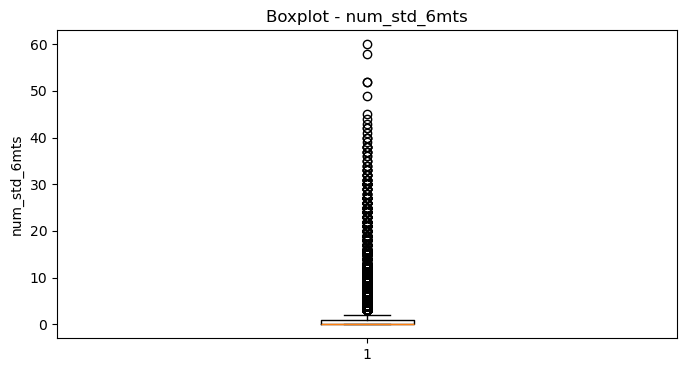

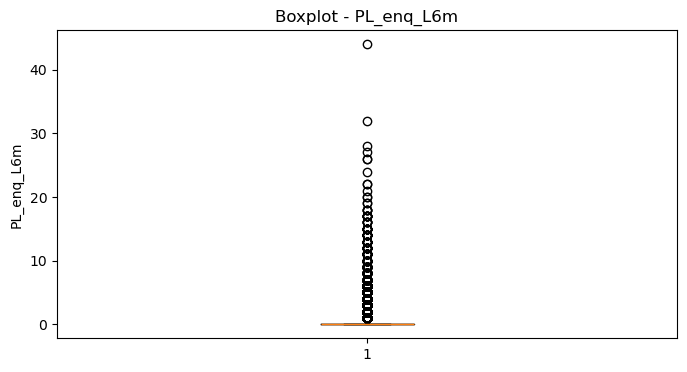

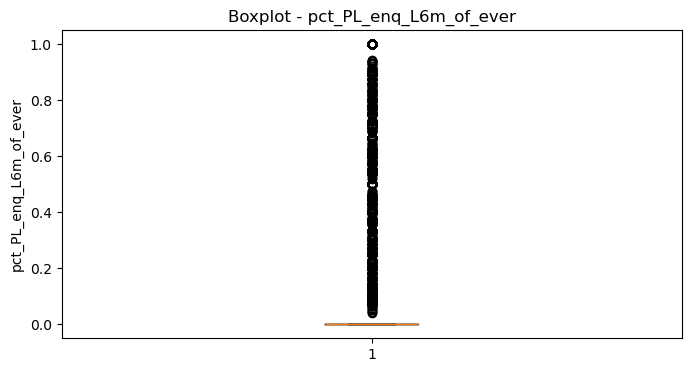

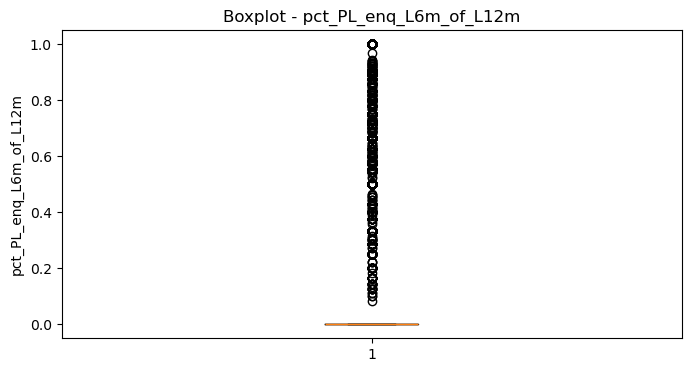

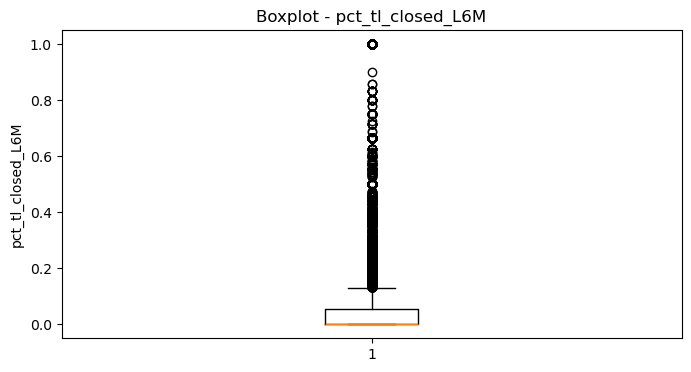

In [72]:
import matplotlib.pyplot as plt

for col in top_outlier_cols:
    plt.figure(figsize=(8, 4))

    plt.boxplot(df[col].dropna())

    plt.title(f"Boxplot - {col}")
    plt.ylabel(col)

    plt.show()

In [73]:
count_outlier = {}

for i in outlier_col:
    q1 = df[i].quantile(0.25)
    q3 = df[i].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr


    outlier = ((df[i]<lower) | (df[i]>upper)).sum()

    count_outlier[i] = outlier

count_outlier = pd.Series(count_outlier).sort_values(ascending=False)


print(count_outlier)

num_std_6mts                  11316
pct_PL_enq_L6m_of_ever        11100
pct_PL_enq_L6m_of_L12m        11100
PL_enq_L6m                    11100
pct_tl_closed_L6M             10473
                              ...  
pct_opened_TLs_L6m_of_L12m        0
pct_active_tl                     0
pct_closed_tl                     0
pct_tl_open_L12M                  0
HL_Flag                           0
Length: 74, dtype: int64


In [74]:
outlier_summary = pd.DataFrame({
    "Min": df[top_outlier_cols].min(),
    "Q1": df[top_outlier_cols].quantile(0.25),
    "Median": df[top_outlier_cols].median(),
    "Q3": df[top_outlier_cols].quantile(0.75),
    "Max": df[top_outlier_cols].max(),
    "Outlier_Count": count_outlier.head(5)
})

print(outlier_summary)

                        Min   Q1  Median     Q3   Max  Outlier_Count
PL_enq_L6m              0.0  0.0     0.0  0.000  44.0          11100
num_std_6mts            0.0  0.0     0.0  1.000  60.0          11316
pct_PL_enq_L6m_of_L12m  0.0  0.0     0.0  0.000   1.0          11100
pct_PL_enq_L6m_of_ever  0.0  0.0     0.0  0.000   1.0          11100
pct_tl_closed_L6M       0.0  0.0     0.0  0.053   1.0          10473


In [75]:
for i in top_outlier_cols:
    print("\n" , i)
    print(df[i].value_counts().head(10))


 num_std_6mts
num_std_6mts
0     37369
4      3529
5      2640
1      1378
3      1346
2      1273
8       669
10      546
6       534
7       422
Name: count, dtype: int64

 PL_enq_L6m
PL_enq_L6m
0.0    40236
1.0     6228
2.0     2479
3.0     1024
4.0      491
5.0      277
6.0      201
7.0      116
8.0       75
9.0       58
Name: count, dtype: int64

 pct_PL_enq_L6m_of_ever
pct_PL_enq_L6m_of_ever
0.000    40236
1.000     6591
0.500     1407
0.333      594
0.667      510
0.250      281
0.750      224
0.400      155
0.200      137
0.600      120
Name: count, dtype: int64

 pct_PL_enq_L6m_of_L12m
pct_PL_enq_L6m_of_L12m
0.000    40236
1.000     8126
0.500     1036
0.667      463
0.333      326
0.750      213
0.800      115
0.250       89
0.600       85
0.400       83
Name: count, dtype: int64

 pct_tl_closed_L6M
pct_tl_closed_L6M
0.000    38021
0.500     1772
0.333     1513
1.000     1449
0.250     1197
0.200      955
0.167      759
0.143      581
0.125      428
0.111      370
Name: coun

In [76]:
col = "NETMONTHLYINCOME"

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower)
print("Upper Bound:", upper)

print("Outliers:",((df[col] < lower) | (df[col] > upper)).sum())

Q1: 18000.0
Q3: 30000.0
IQR: 12000.0
Lower Bound: 0.0
Upper Bound: 48000.0
Outliers: 3106


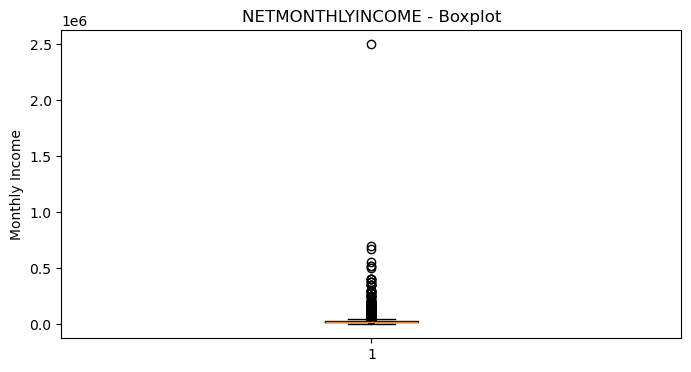

In [77]:
plt.figure(figsize=(8,4))

plt.boxplot(df[col].dropna())

plt.title("NETMONTHLYINCOME - Boxplot")
plt.ylabel("Monthly Income")

plt.show()

In [78]:
income_outlier_count = ((df["NETMONTHLYINCOME"] < lower) | 
                        (df["NETMONTHLYINCOME"] > upper)).sum()

income_outlier_percent = (income_outlier_count / len(df)) * 100

print("Outlier Count:", income_outlier_count)
print("Outlier Percentage:", income_outlier_percent)

Outlier Count: 3106
Outlier Percentage: 6.050335047529998


In [79]:
df["NETMONTHLYINCOME"].sort_values(ascending=False).head(20)

22238    2500000
10851     700000
2673      670000
47484     554640
24353     520000
50508     520000
38128     500000
43550     400000
18184     400000
46114     400000
5213      400000
46654     380000
39125     380000
19344     380000
16283     350000
7833      350000
12791     350000
4913      350000
32441     350000
2008      308568
Name: NETMONTHLYINCOME, dtype: int64

In [80]:
high_income = df[df["NETMONTHLYINCOME"] > upper]["NETMONTHLYINCOME"]

high_income.describe()


count    3.106000e+03
mean     6.807135e+04
std      5.930521e+04
min      4.845500e+04
25%      5.000000e+04
50%      5.600000e+04
75%      7.000000e+04
max      2.500000e+06
Name: NETMONTHLYINCOME, dtype: float64

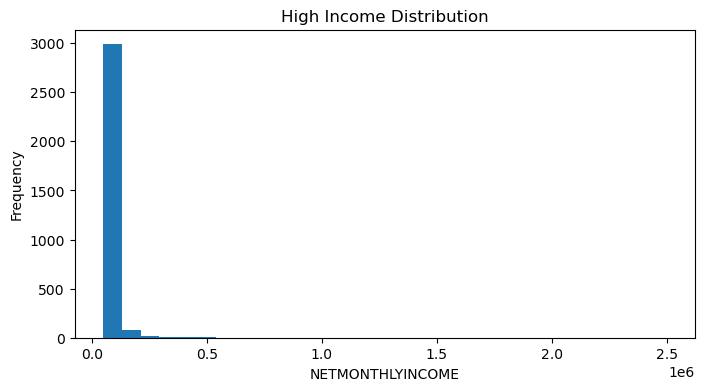

In [81]:
plt.figure(figsize=(8, 4))

plt.hist(high_income, bins=30)

plt.title("High Income Distribution")
plt.xlabel("NETMONTHLYINCOME")
plt.ylabel("Frequency")

plt.show()

In [82]:
continuous_cols = [ "AGE","NETMONTHLYINCOME","Time_With_Curr_Empr","Credit_Score"]

for col in continuous_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"\n{col}")
    print("Lower:", lower)
    print("Upper:", upper)
    print("Outliers:", outliers)


AGE
Lower: 9.0
Upper: 57.0
Outliers: 582

NETMONTHLYINCOME
Lower: 0.0
Upper: 48000.0
Outliers: 3106

Time_With_Curr_Empr
Lower: -44.0
Upper: 236.0
Outliers: 4154

Credit_Score
Lower: 636.0
Upper: 724.0
Outliers: 2106


In [83]:
print((df["Time_With_Curr_Empr"] < 0).sum())

print(df.loc[df["Time_With_Curr_Empr"] < 0, "Time_With_Curr_Empr"].value_counts())

0
Series([], Name: count, dtype: int64)


In [84]:
df["Approved_Flag"].value_counts()

Approved_Flag
P2    32199
P3     7452
P4     5882
P1     5803
Name: count, dtype: int64

In [87]:
feature_cols = []
for i in numeric_cols:
    if col != "PROSPECTID":
        feature_cols.append(i)
group_mean = df.groupby("Approved_Flag")[feature_cols].mean()

group_mean

,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,...,pct_currentBal_all_TL,CC_Flag,PL_Flag,pct_PL_enq_L6m_of_L12m,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,HL_Flag,GL_Flag,Credit_Score
Approved_Flag,,,,,,,,,,,,,,,,,,,,,
P1,26140.230915,9.923316,6.701361,3.221954,0.785283,0.622092,0.078635,0.059074,0.401540,0.598460,...,0.679594,0.136653,0.277615,0.062123,0.036184,0.043185,0.027988,0.475444,0.155781,715.952266
P2,25680.355011,4.060530,2.215473,1.845057,0.607100,0.373397,0.160502,0.087737,0.589142,0.410858,...,0.828197,0.076493,0.140222,0.114041,0.042971,0.099268,0.036577,0.251281,0.043045,682.584614
P3,25247.937735,4.269055,2.235776,2.033280,0.853596,0.437332,0.266842,0.103168,0.631325,0.368675,...,0.544937,0.089775,0.157676,0.324706,0.080003,0.298835,0.070293,0.223027,0.035695,666.995035
P4,25671.025672,4.977559,2.607446,2.370112,1.250595,0.531622,0.316641,0.108317,0.619541,0.380459,...,1.400433,0.113567,0.223903,0.564922,0.196597,0.523383,0.174487,0.239034,0.027032,645.629548


In [88]:
# ANOVA

In [90]:
from scipy.stats import f_oneway

In [102]:
group = []

for i in df["Approved_Flag"].unique():
    group.append(
        df[df["Approved_Flag"] == i]["Credit_Score"]
    )

print(group)

f_stat, p_value = f_oneway(*group)

print("F-statistic:", f_stat)
print("p-value:", p_value)

[0        696
1        685
2        693
3        673
7        676
        ... 
51327    669
51328    672
51330    670
51334    686
51335    681
Name: Credit_Score, Length: 32199, dtype: int64, 4        753
6        703
9        705
19       720
28       740
        ... 
51301    737
51323    731
51324    718
51325    713
51332    702
Name: Credit_Score, Length: 5803, dtype: int64, 5        668
24       702
26       660
33       663
41       663
        ... 
51276    666
51284    665
51285    662
51329    661
51333    661
Name: Credit_Score, Length: 7452, dtype: int64, 8        658
15       643
31       638
38       657
45       651
        ... 
51241    631
51277    655
51280    652
51296    644
51331    650
Name: Credit_Score, Length: 5882, dtype: int64]
F-statistic: 48176.395727573276
p-value: 0.0


In [108]:
anova = []

for col in feature_cols:
    group = [df[df["Approved_Flag"] == j][col].dropna()
        for j in df["Approved_Flag"].unique() ]

    f_stat, p_value = f_oneway(*group)

    anova.append({"Feature": col,"F_statistic": f_stat,"p_value": p_value})

anova = pd.DataFrame(anova)

print(anova.sort_values("p_value"))

                  Feature  F_statistic   p_value
37           num_std_6mts  3803.408803  0.000000
36                num_std  4489.884287  0.000000
38          num_std_12mts  4472.589909  0.000000
49                tot_enq  2149.255426  0.000000
51             CC_enq_L6m   958.563536  0.000000
..                    ...          ...       ...
43           num_dbt_6mts     2.576416  0.051963
40           num_sub_6mts     2.293374  0.075832
47          num_lss_12mts     1.058976  0.365152
65  pct_currentBal_all_TL     0.651967  0.581614
46           num_lss_6mts     0.640636  0.588776

[75 rows x 3 columns]


In [109]:
anova["Significant"] = anova["p_value"] < 0.05

print(anova.sort_values("p_value"))

                  Feature  F_statistic   p_value  Significant
37           num_std_6mts  3803.408803  0.000000         True
36                num_std  4489.884287  0.000000         True
38          num_std_12mts  4472.589909  0.000000         True
49                tot_enq  2149.255426  0.000000         True
51             CC_enq_L6m   958.563536  0.000000         True
..                    ...          ...       ...          ...
43           num_dbt_6mts     2.576416  0.051963        False
40           num_sub_6mts     2.293374  0.075832        False
47          num_lss_12mts     1.058976  0.365152        False
65  pct_currentBal_all_TL     0.651967  0.581614        False
46           num_lss_6mts     0.640636  0.588776        False

[75 rows x 4 columns]


In [110]:
print(anova["Significant"].value_counts())

Significant
True     70
False     5
Name: count, dtype: int64


In [111]:
significant_features = anova.loc[
    anova["p_value"] < 0.05, "Feature"
]

print(significant_features.tolist())

['PROSPECTID', 'Total_TL', 'Tot_Closed_TL', 'Tot_Active_TL', 'Total_TL_opened_L6M', 'Tot_TL_closed_L6M', 'pct_tl_open_L6M', 'pct_tl_closed_L6M', 'pct_active_tl', 'pct_closed_tl', 'Total_TL_opened_L12M', 'Tot_TL_closed_L12M', 'pct_tl_open_L12M', 'pct_tl_closed_L12M', 'Tot_Missed_Pmnt', 'Auto_TL', 'CC_TL', 'Consumer_TL', 'Gold_TL', 'Home_TL', 'PL_TL', 'Secured_TL', 'Unsecured_TL', 'Other_TL', 'Age_Oldest_TL', 'Age_Newest_TL', 'time_since_recent_payment', 'num_times_delinquent', 'max_recent_level_of_deliq', 'num_deliq_6mts', 'num_deliq_12mts', 'num_deliq_6_12mts', 'max_deliq_6mts', 'max_deliq_12mts', 'num_times_30p_dpd', 'num_times_60p_dpd', 'num_std', 'num_std_6mts', 'num_std_12mts', 'num_sub', 'num_sub_12mts', 'num_dbt', 'num_dbt_12mts', 'num_lss', 'recent_level_of_deliq', 'tot_enq', 'CC_enq', 'CC_enq_L6m', 'CC_enq_L12m', 'PL_enq', 'PL_enq_L6m', 'PL_enq_L12m', 'time_since_recent_enq', 'enq_L12m', 'enq_L6m', 'enq_L3m', 'AGE', 'NETMONTHLYINCOME', 'Time_With_Curr_Empr', 'pct_of_active_TLs_

In [112]:
significant_features = anova.loc[
    (anova["p_value"] < 0.05) &
    (anova["Feature"] != "PROSPECTID"),
    "Feature"
].tolist()

print("Number of Significant Features:", len(significant_features))
print(significant_features)

Number of Significant Features: 69
['Total_TL', 'Tot_Closed_TL', 'Tot_Active_TL', 'Total_TL_opened_L6M', 'Tot_TL_closed_L6M', 'pct_tl_open_L6M', 'pct_tl_closed_L6M', 'pct_active_tl', 'pct_closed_tl', 'Total_TL_opened_L12M', 'Tot_TL_closed_L12M', 'pct_tl_open_L12M', 'pct_tl_closed_L12M', 'Tot_Missed_Pmnt', 'Auto_TL', 'CC_TL', 'Consumer_TL', 'Gold_TL', 'Home_TL', 'PL_TL', 'Secured_TL', 'Unsecured_TL', 'Other_TL', 'Age_Oldest_TL', 'Age_Newest_TL', 'time_since_recent_payment', 'num_times_delinquent', 'max_recent_level_of_deliq', 'num_deliq_6mts', 'num_deliq_12mts', 'num_deliq_6_12mts', 'max_deliq_6mts', 'max_deliq_12mts', 'num_times_30p_dpd', 'num_times_60p_dpd', 'num_std', 'num_std_6mts', 'num_std_12mts', 'num_sub', 'num_sub_12mts', 'num_dbt', 'num_dbt_12mts', 'num_lss', 'recent_level_of_deliq', 'tot_enq', 'CC_enq', 'CC_enq_L6m', 'CC_enq_L12m', 'PL_enq', 'PL_enq_L6m', 'PL_enq_L12m', 'time_since_recent_enq', 'enq_L12m', 'enq_L6m', 'enq_L3m', 'AGE', 'NETMONTHLYINCOME', 'Time_With_Curr_Empr'

In [113]:
# chi - Square

In [114]:
from scipy.stats import chi2_contingency

In [115]:
table = pd.crosstab(df["MARITALSTATUS"], df["Approved_Flag"])

print(table)

Approved_Flag    P1     P2    P3    P4
MARITALSTATUS                         
Married        5215  23697  5087  3753
Single          588   8502  2365  2129


In [116]:
chi2, p_value, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", dof)

Chi-square: 1188.1293579981798
p-value: 2.7588304433709322e-257
Degrees of freedom: 3


In [118]:
categorical_features = []
for col in object_cols:
    if col != "Approved_Flag":
        categorical_features.append(col)

chi_results = []

for col in categorical_features:
    table = pd.crosstab(df[col], df["Approved_Flag"])

    chi2, p_value, dof, expected = chi2_contingency(table)

    chi_results.append({
        "Feature": col,
        "Chi2": chi2,
        "p_value": p_value,
        "dof": dof,
        "Significant": p_value < 0.05 })

chi_results = pd.DataFrame(chi_results)

print(chi_results.sort_values("p_value"))

           Feature         Chi2        p_value  dof  Significant
3   last_prod_enq2  3728.514629   0.000000e+00   15         True
4  first_prod_enq2  1833.116465   0.000000e+00   15         True
0    MARITALSTATUS  1188.129358  2.758830e-257    3         True
1        EDUCATION   225.246136   8.464676e-38   18         True
2           GENDER    19.229726   2.450668e-04    3         True


In [ ]:
# Matplotlib 

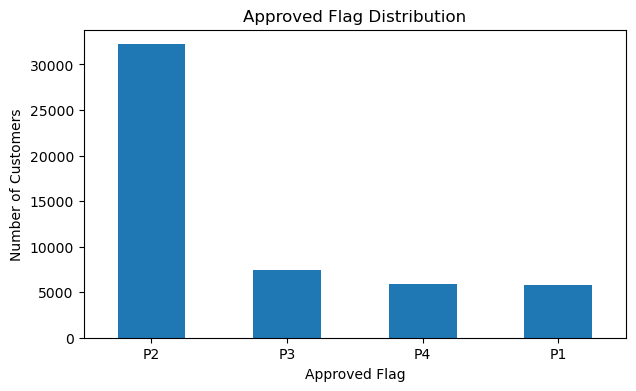

In [121]:
df["Approved_Flag"].value_counts().plot(
    kind="bar",
    figsize=(7, 4))

plt.title("Approved Flag Distribution")
plt.xlabel("Approved Flag")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

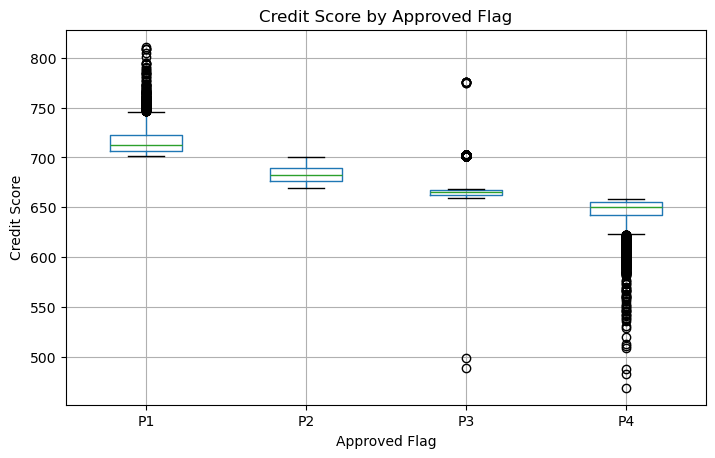

In [124]:
df.boxplot(
    column="Credit_Score",
    by="Approved_Flag",
    figsize=(8, 5))

plt.title("Credit Score by Approved Flag")
plt.suptitle("")
plt.xlabel("Approved Flag")
plt.ylabel("Credit Score")

plt.show()

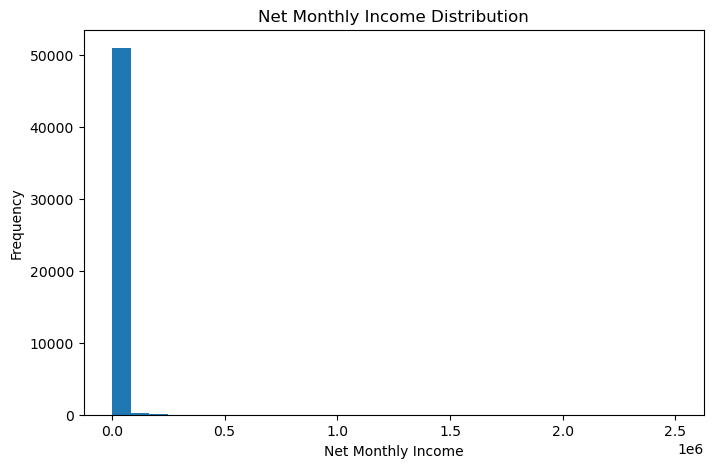

In [125]:
plt.figure(figsize=(8, 5))

plt.hist(df["NETMONTHLYINCOME"], bins=30)

plt.title("Net Monthly Income Distribution")
plt.xlabel("Net Monthly Income")
plt.ylabel("Frequency")

plt.show()

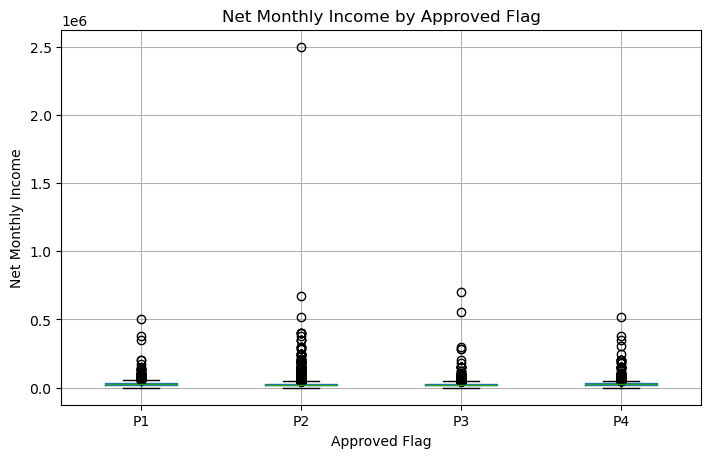

In [126]:
df.boxplot(
    column="NETMONTHLYINCOME",
    by="Approved_Flag",
    figsize=(8, 5)
)

plt.title("Net Monthly Income by Approved Flag")
plt.suptitle("")
plt.xlabel("Approved Flag")
plt.ylabel("Net Monthly Income")

plt.show()

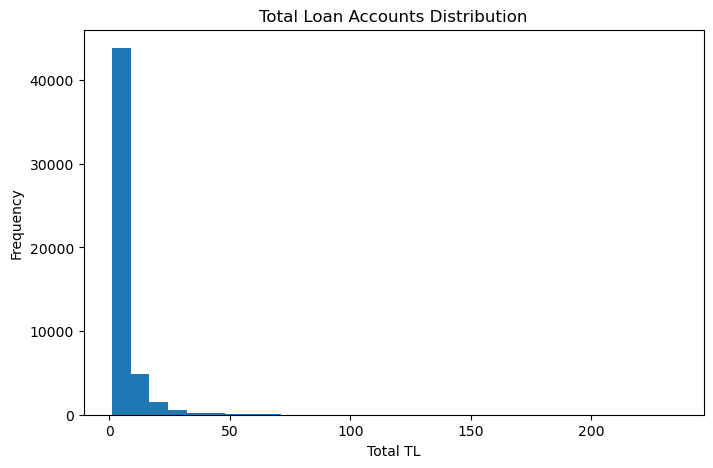

In [127]:
plt.figure(figsize=(8, 5))

plt.hist(df["Total_TL"], bins=30)

plt.title("Total Loan Accounts Distribution")
plt.xlabel("Total TL")
plt.ylabel("Frequency")

plt.show()

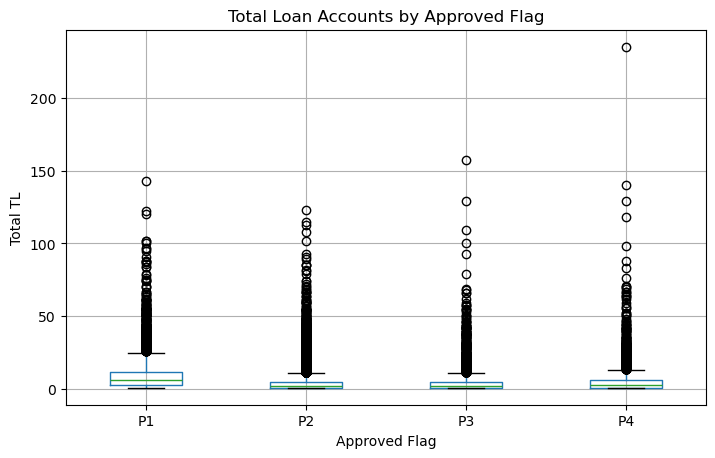

In [128]:
df.boxplot(
    column="Total_TL",
    by="Approved_Flag",
    figsize=(8, 5)
)

plt.title("Total Loan Accounts by Approved Flag")
plt.suptitle("")
plt.xlabel("Approved Flag")
plt.ylabel("Total TL")

plt.show()

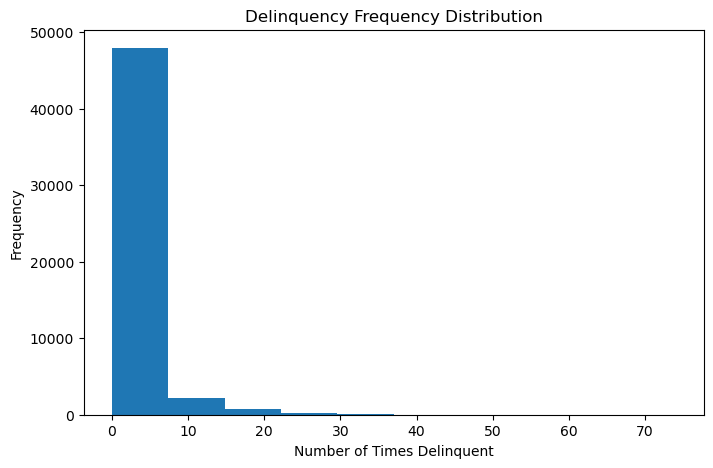

In [130]:
plt.figure(figsize=(8, 5))

plt.hist(df["num_times_delinquent"], bins=10)

plt.title("Delinquency Frequency Distribution")
plt.xlabel("Number of Times Delinquent")
plt.ylabel("Frequency")

plt.show()

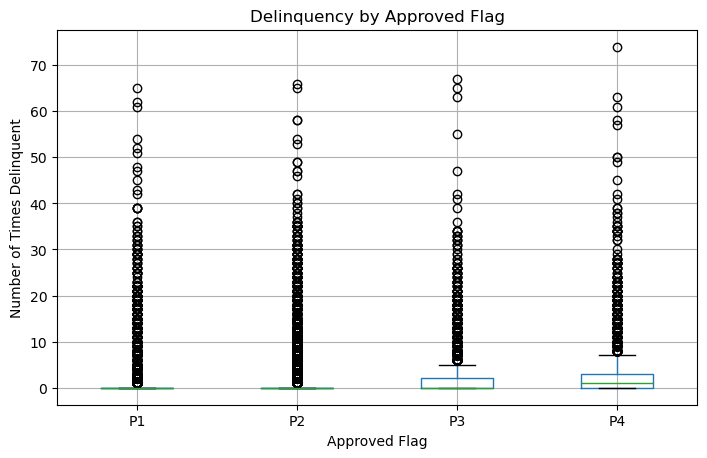

In [131]:
df.boxplot(
    column="num_times_delinquent",
    by="Approved_Flag",
    figsize=(8, 5)
)

plt.title("Delinquency by Approved Flag")
plt.suptitle("")
plt.xlabel("Approved Flag")
plt.ylabel("Number of Times Delinquent")

plt.show()

In [132]:
import seaborn as sns

In [133]:
top_corr = corr.abs().where(
    np.triu(np.ones(corr.shape), k=1).astype(bool))

top_features = (
    top_corr.stack()
    .sort_values(ascending=False)
    .head(15))

print(top_features)

pct_closed_tl           pct_of_active_TLs_ever    1.000000
pct_active_tl           pct_closed_tl             1.000000
                        pct_of_active_TLs_ever    1.000000
pct_PL_enq_L6m_of_L12m  pct_PL_enq_L6m_of_ever    0.965067
pct_CC_enq_L6m_of_L12m  pct_CC_enq_L6m_of_ever    0.962371
num_std_6mts            num_std_12mts             0.957949
Total_TL                Tot_Closed_TL             0.956367
Gold_TL                 Secured_TL                0.931372
Tot_Closed_TL           Secured_TL                0.930788
enq_L12m                enq_L6m                   0.926873
num_dbt_6mts            num_dbt_12mts             0.926526
num_times_30p_dpd       num_times_60p_dpd         0.920042
num_deliq_12mts         num_deliq_6_12mts         0.916986
num_lss_6mts            num_lss_12mts             0.916809
PL_enq_L6m              PL_enq_L12m               0.909703
dtype: float64


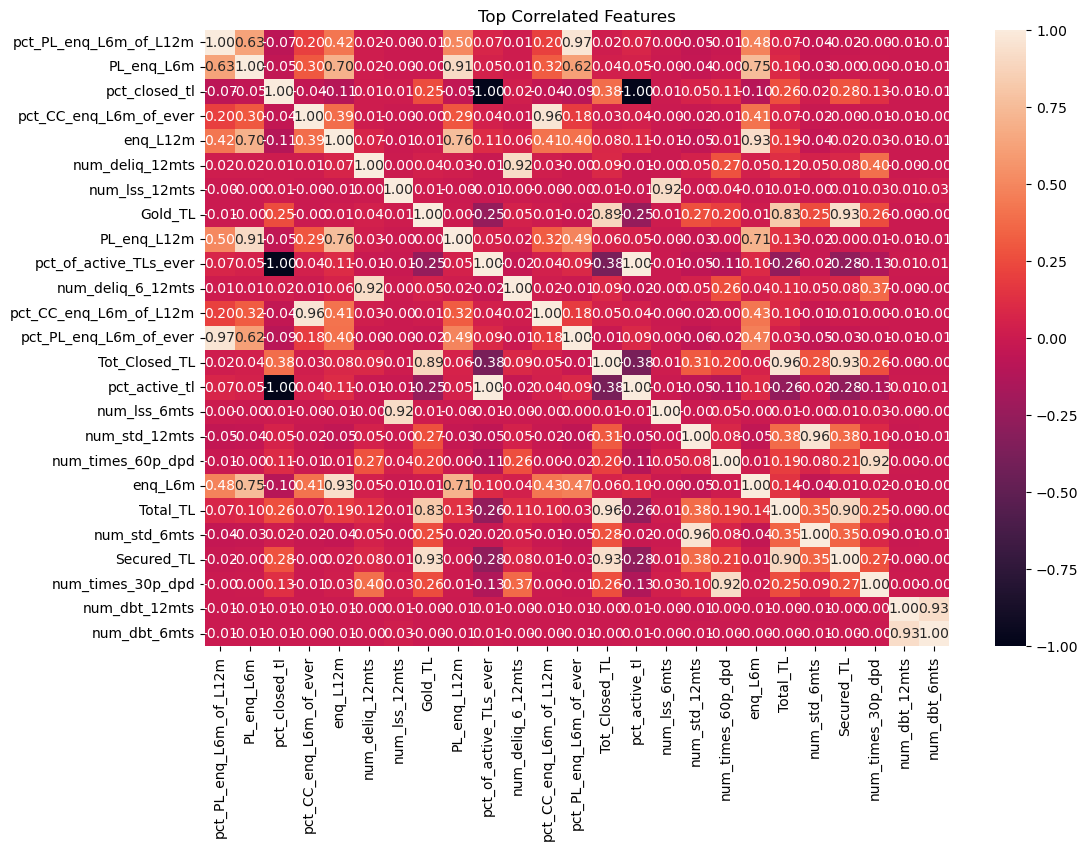

In [134]:
features = list(set(top_features.index.get_level_values(0)) |
                set(top_features.index.get_level_values(1)))

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr.loc[features, features],
    annot=True,
    fmt=".2f"
)

plt.title("Top Correlated Features")
plt.show()

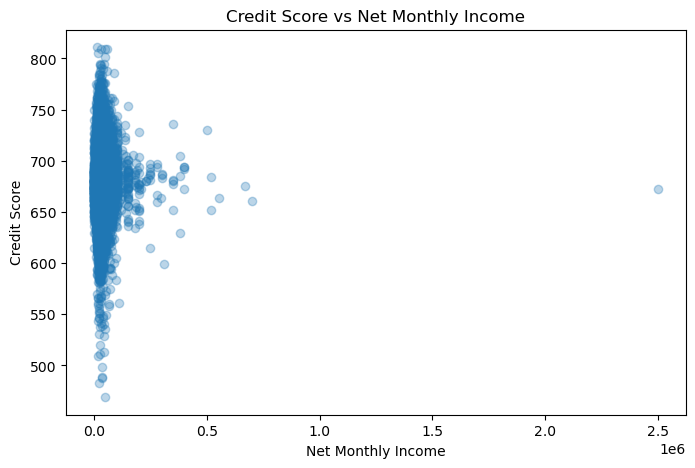

In [136]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["NETMONTHLYINCOME"],
    df["Credit_Score"],
    alpha=0.3)

plt.title("Credit Score vs Net Monthly Income")
plt.xlabel("Net Monthly Income")
plt.ylabel("Credit Score")

plt.show()

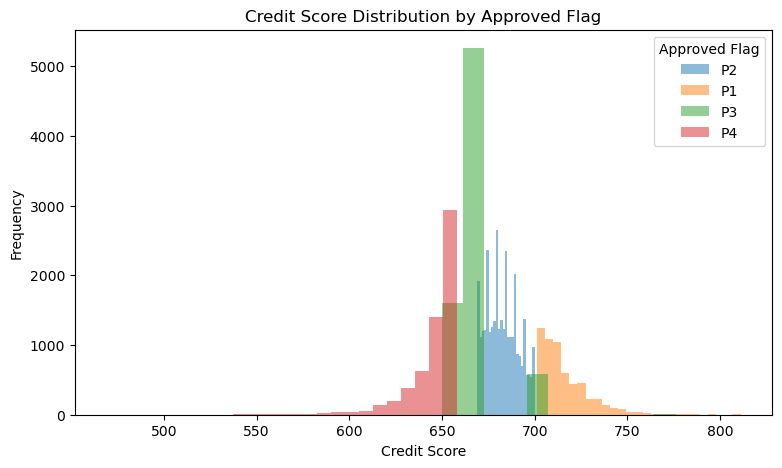

In [139]:
plt.figure(figsize=(9, 5))

for flag in df["Approved_Flag"].unique():
    plt.hist(
        df[df["Approved_Flag"] == flag]["Credit_Score"],
        bins=25,
        alpha=0.5,
        label=flag)

plt.title("Credit Score Distribution by Approved Flag")
plt.xlabel("Credit Score")
plt.ylabel("Frequency")
plt.legend(title="Approved Flag")

plt.show()

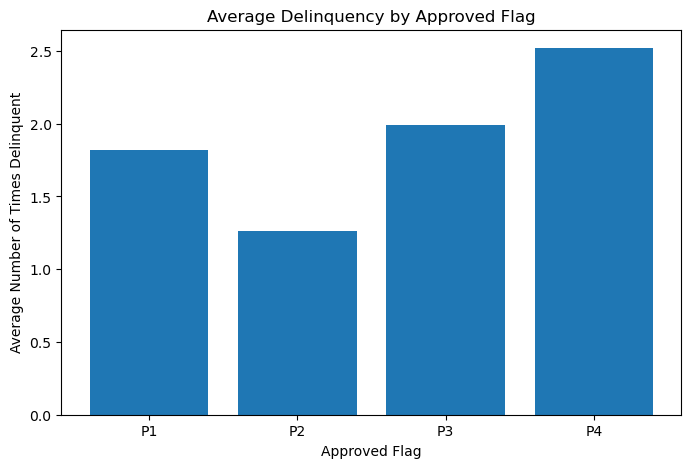

In [140]:
mean_deliq = df.groupby("Approved_Flag")["num_times_delinquent"].mean()

plt.figure(figsize=(8, 5))

plt.bar(mean_deliq.index,mean_deliq.values)

plt.title("Average Delinquency by Approved Flag")
plt.xlabel("Approved Flag")
plt.ylabel("Average Number of Times Delinquent")

plt.show()

In [142]:
# Group-wise important metrics

In [144]:
summary = df.groupby("Approved_Flag")[
    ["Credit_Score", "NETMONTHLYINCOME", "Total_TL", "num_times_delinquent"]].mean()

print(summary)

               Credit_Score  NETMONTHLYINCOME  Total_TL  num_times_delinquent
Approved_Flag                                                                
P1               715.952266      29071.369292  9.923316              1.819921
P2               682.584614      25886.794093  4.060530              1.260319
P3               666.995035      25938.472088  4.269055              1.989801
P4               645.629548      27369.680551  4.977559              2.519551


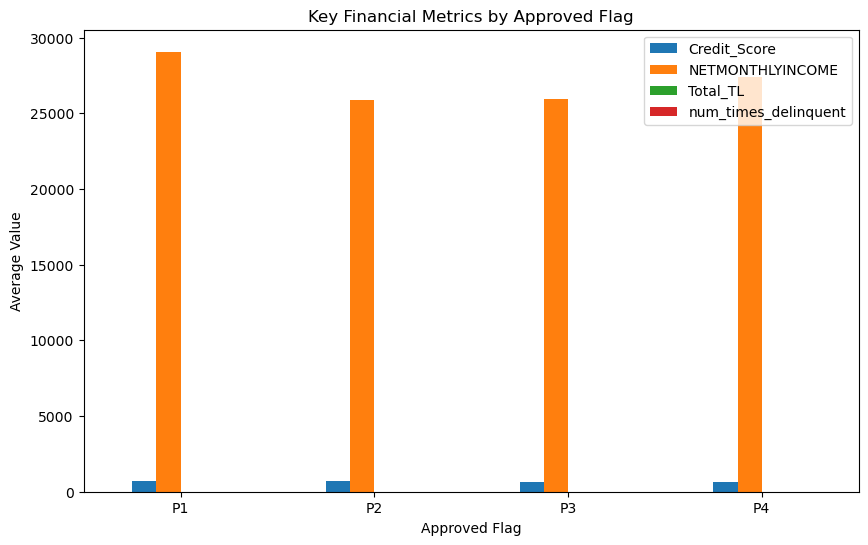

In [145]:
summary.plot(
    kind="bar",
    figsize=(10, 6))

plt.title("Key Financial Metrics by Approved Flag")
plt.xlabel("Approved Flag")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend()

plt.show()

In [146]:
flag_pct = (
    df["Approved_Flag"]
    .value_counts(normalize=True)
    .mul(100)
    .sort_index()
)

print(flag_pct)

Approved_Flag
P1    11.303958
P2    62.722066
P3    14.516129
P4    11.457846
Name: proportion, dtype: float64


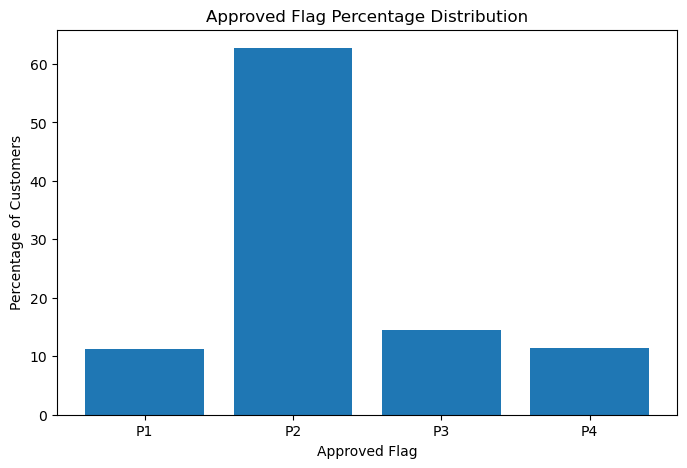

In [147]:
plt.figure(figsize=(8, 5))

plt.bar(flag_pct.index, flag_pct.values)

plt.title("Approved Flag Percentage Distribution")
plt.xlabel("Approved Flag")
plt.ylabel("Percentage of Customers")

plt.show()

In [ ]:
# Important metrics ka comparison

In [ ]:
| Metric         |     P1 |     P2 |     P3 |     P4 |
| -------------- | -----: | -----: | -----: | -----: |
| Credit Score   | 715.95 | 682.58 | 667.00 | 645.63 |
| Monthly Income | 29,071 | 25,887 | 25,938 | 27,370 |
| Total TL       |   9.92 |   4.06 |   4.27 |   4.98 |
| Delinquency    |   1.82 |   1.26 |   1.99 |   2.52 |


In [148]:
# insight's

In [ ]:
#Credit Score:- 
# P1 ka average credit score 715.95 hai,jo P4 ke 645.63 se kaafi higher hai. 
# Tumhare ANOVA mein Credit Score ka p-value bhi extremely small tha,
# so approval groups ke means mein statistically significant difference mila.

In [ ]:
# Delinquency:- 
# P4 ka average delinquency 2.52 hai, jo P1 ke 1.82 aur P2 ke 1.26 se higher hai.
# Ye P4 group mein comparatively higher delinquency exposure ko indicate karta hai.

In [ ]:
# Loan accounts:-
# P1 ka average Total_TL 9.92 hai, jabki P2 ka 4.06.
# Isse approval groups ke credit-account profiles mein substantial difference dikhta hai.

In [ ]:
# Income:-
# Income ka pattern Credit Score jaisa monotonic nahi hai.
# P1 = 29,071, P2 = 25,887, P3 = 25,938, P4 = 27,370
# Isliye sirf income ke basis par approval categories ko explain karna appropriate nahi hoga.

In [149]:
# Portfolio distribution:-
# Dataset ka 62.72% P2 category mein hai, jabki P1/P3/P4 each roughly 11–15% hain.
# Isliye overall dataset ka majority customer profile P2 category se represent hota hai.

In [ ]:
# Dataset quality achhi hai: merge ke baad 51,336 records aur missing values 0.
# Numerical variables mein multiple statistically significant differences Approved_Flag groups ke across mile.
# ANOVA mein 69 features significant aaye (p < 0.05).
# Chi-square mein 5/5 categorical features significant aaye.
# Credit Score groups ke saath strongly differ karta hai: P1 715.95 vs P4 645.63.
# Delinquency P4 mein comparatively higher hai: 2.52.
# P2 dataset ka largest segment hai: 62.72%.
# Outlier analysis ne kuch financial variables, especially income, mein extreme observations identify kiye.